**Task no 2**
# Stock Price Prediction Using Machine Learning

Purpose: This project predicts the next day's closing stock price using historical stock market data from Yahoo Finance.

**1. Install Library**

Purpose:

Install the yfinance library to fetch stock market data directly from Yahoo Finance.

In [1]:
!pip install yfinance

**2. Import Libraries**

Purpose:

Import all required libraries for data collection, preprocessing, visualization, model training, and evaluation.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**3. Download Stock Data**

Purpose:

Retrieve historical stock market data for Apple (AAPL) from Yahoo Finance.

In [3]:
stock_data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

stock_data.head()

/tmp/ipykernel_4787/839885487.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200


**4. Dataset Shape**

Purpose:

Check the number of rows and columns in the dataset.

In [4]:
print("Dataset Shape:", stock_data.shape)

Dataset Shape: (1258, 5)


**5. Basic Dataset Information**

Purpose:

Display column names, data types, and non-null values to understand the dataset structure.

In [5]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


**6. Statistical Summary**

Purpose:

Generate summary statistics to understand the distribution of stock prices and trading volume.

In [6]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377787,152.899567,149.680872,151.223471,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163704,55.160702,51.324800,55.059313,2.323470e+07
25%,126.279119,127.397087,124.278521,125.724401,5.546825e+07
50%,149.968597,151.709757,148.037179,149.788890,7.628335e+07
75%,175.902031,177.452417,174.337226,175.708238,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


**Preprocessing**

**7. Check Missing Values**

Purpose:

Identify any missing values that could affect model performance.

In [7]:
stock_data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


**8. Handle Missing Values**

Purpose:

Remove rows containing missing values to ensure clean data for modeling.

In [8]:
stock_data = stock_data.dropna()

print("Remaining Missing Values:")
print(stock_data.isnull().sum())

Remaining Missing Values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


**9. Display Sample Records**

Purpose:

View a few rows of the cleaned dataset to verify data quality.

In [9]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200


**10. Visualize Closing Price Trend**

Purpose:

Plot the historical closing price trend to understand stock price movement over time.

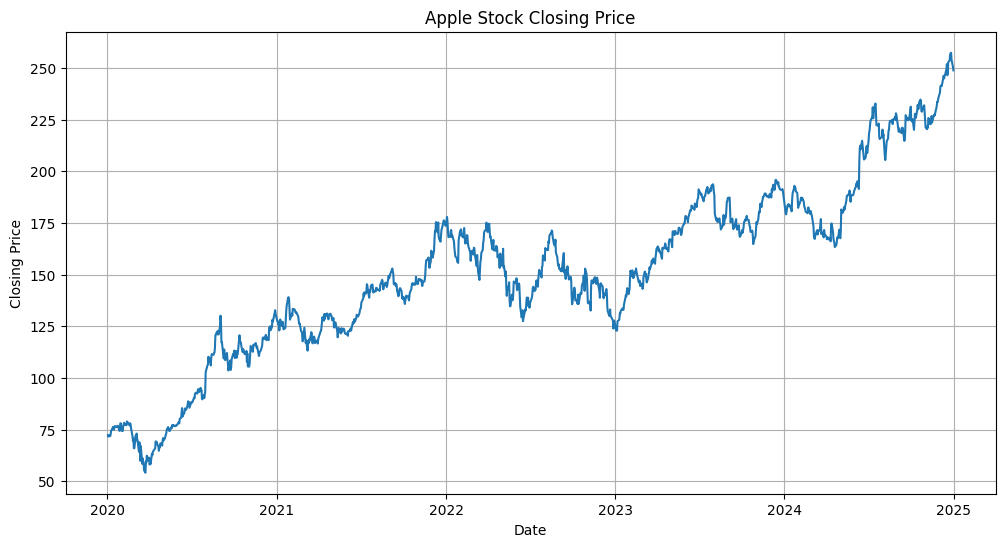

In [10]:
plt.figure(figsize=(12,6))
plt.plot(stock_data['Close'])

plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)

plt.show()

**11. Create Target Variable**

Purpose:

Create the target variable by shifting the closing price one day forward to represent the next day's closing price.

In [11]:
stock_data['Next_Close'] = stock_data['Close'].shift(-1)

stock_data.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,71.630653
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800,72.201424
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,71.861839
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,73.017822
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,74.568810


**12. Remove Last Row**

Purpose:

Remove the last row because it does not have a next-day closing price.

In [12]:
stock_data = stock_data.dropna()

stock_data.tail()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-12-23,253.649445,254.027022,251.840991,253.152619,40858800,256.560852
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,257.375580
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,253.967392
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,250.598907
2024-12-30,250.598907,251.890657,249.158116,250.628716,35557500,248.830231


**13. Select Features and Target**

Purpose:

Define input features and the target variable for machine learning.

In [13]:
X = stock_data[['Open', 'High', 'Low', 'Volume']]

y = stock_data['Next_Close']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1257, 4)
Target Shape: (1257,)


**14. Split Data**

Purpose:

Split the dataset into training and testing sets for unbiased model evaluation.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1005
Testing Samples: 252


**Model Training**

**15. Train Linear Regression Model**

Purpose:

Train a Linear Regression model to learn the relationship between stock features and the next day's closing price.

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

**16. Make Predictions**

Purpose:

Generate predicted closing prices using the trained model.

In [16]:
y_pred = model.predict(X_test)

y_pred[:5]

array([143.05372237,  78.22306594,  60.41245433,  58.72468047,
       167.23492401])

**17. Evaluate Model**

Purpose:

Measure prediction accuracy using standard regression evaluation metrics.

In [17]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

MAE : 2.0862
MSE : 8.2935
RMSE: 2.8799
R² Score: 0.9953


**18. Actual vs Predicted Values**

Purpose:

Compare actual and predicted stock prices using a table.

In [18]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,143.425125,143.053722
1,76.959587,78.223066
2,59.547009,60.412454
3,58.277229,58.724680
4,167.985031,167.234924
5,151.420303,152.989167
6,182.321198,182.616279
7,154.320877,160.122395
8,222.806473,221.235461
9,182.034088,181.380832


**19. Plot Actual vs Predicted**

Purpose:

Visualize how closely the predicted prices match the actual stock prices.

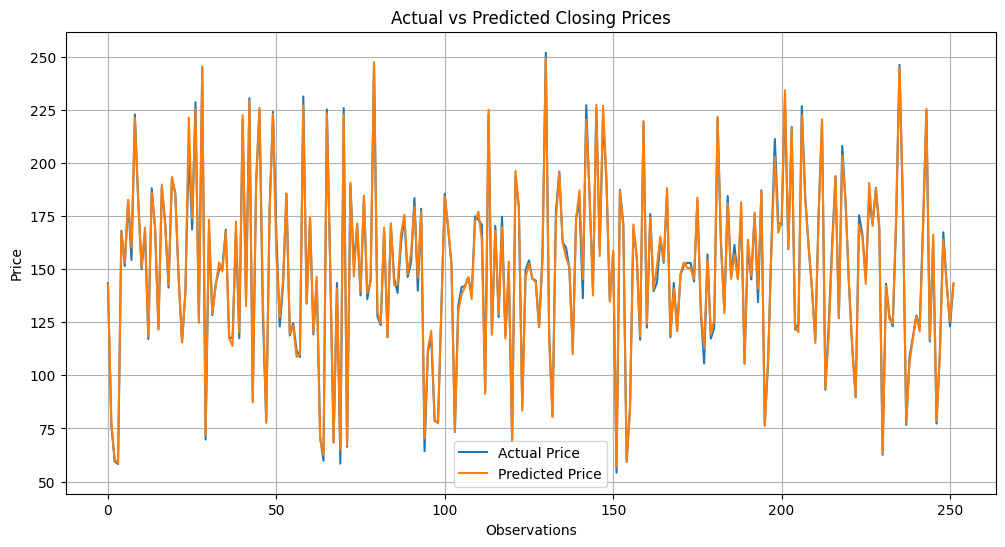

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    y_pred,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Closing Prices')

plt.xlabel('Observations')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.show()

**20. Predict Tomorrow's Closing Price**

Purpose:

Use the latest available stock data to estimate the next day's closing price.

In [20]:
latest_data = X.iloc[-1:]

next_day_prediction = model.predict(latest_data)

print(
    "Predicted Next Day Closing Price:",
    round(next_day_prediction[0], 2)
)

Predicted Next Day Closing Price: 250.75
